# **MIE1517: DeepFashion2 Dataset Analysis**

In [ ]:
#Core imports
import os
import json
from pathlib import Path
from collections import defaultdict

#Data handling
import numpy as np
import pandas as pd
import csv

#Image processing
from PIL import Image
import PIL
import matplotlib.pyplot as plt

## Config

In [ ]:
DATA_ROOT = "/content/validation"
ANNOS_DIR = "/content/validation/annos"
IMAGE_ROOT = "/content/validation/image"
METADATA_CSV = "/content/metadata.csv"

TARGET_SAMPLES = 5000
TARGET_CATEGORIES = {1, 8}
IMG_SIZE = 224

## Data Aquisition

**DeepFashion2:**
This dataset contains 491K images of 13 different clothing types. The images are accompanied by json files with information regarding the source (user or store photo), and each item in the photo (includes bounding box coordinates, style, category, etc.).

Source URL: https://drive.google.com/uc?id=1O45YqhREBOoLudjA06HcTehcEebR0o9y

Given the vast amounts of data, we created our data splits based on the Validation.zip file.

In [3]:
!pip install --quiet gdown

In [4]:
import gdown

# Import the data from the google drive provided by the DeepFashion2 research team
train_id = "1lQZOIkO-9L0QJuk_w1K8-tRuyno-KvLK"
val_id = "1O45YqhREBOoLudjA06HcTehcEebR0o9y"
test_id = "1hsa-UE-LX8sks8eAcGLL-9QDNyNt6VgP" # Test data does not include json data for each image

file_id = val_id
url = f"https://drive.google.com/uc?id={file_id}"
output = "validation.zip"  # Desired filename

gdown.download(url, output, quiet=False)

Downloading...
From (original): https://drive.google.com/uc?id=1O45YqhREBOoLudjA06HcTehcEebR0o9y
From (redirected): https://drive.google.com/uc?id=1O45YqhREBOoLudjA06HcTehcEebR0o9y&confirm=t&uuid=4f99b70a-ee43-475f-b953-5fba64524ba0
To: /content/validation.zip
100%|██████████| 1.82G/1.82G [00:17<00:00, 101MB/s]


'validation.zip'

In [5]:
# Unzip the file and apply the provided password
!unzip -P '2019Deepfashion2**' validation.zip

# Check folders
print(os.listdir("/content/validation"))
print("annos:", os.path.exists("/content/validation/annos"))
print("image:", os.path.exists("/content/validation/image"))

Streaming output truncated to the last 5000 lines.
  inflating: validation/image/007274.jpg  
  inflating: validation/image/007218.jpg  
  inflating: validation/image/007216.jpg  
  inflating: validation/image/007204.jpg  
  inflating: validation/image/007133.jpg  
  inflating: validation/image/007081.jpg  
  inflating: validation/image/007045.jpg  
  inflating: validation/image/007044.jpg  
  inflating: validation/image/007017.jpg  
  inflating: validation/image/006960.jpg  
  inflating: validation/image/006868.jpg  
  inflating: validation/image/006831.jpg  
  inflating: validation/image/006773.jpg  
  inflating: validation/image/006744.jpg  
  inflating: validation/image/006720.jpg  
  inflating: validation/image/006711.jpg  
  inflating: validation/image/006696.jpg  
  inflating: validation/image/006591.jpg  
  inflating: validation/image/006587.jpg  
  inflating: validation/image/006563.jpg  
  inflating: validation/image/006523.jpg  
  inflating: validation/image/006476.jpg  
  i

## Data Processing

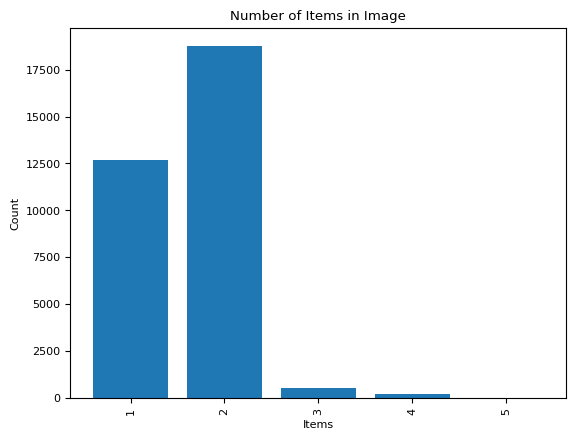

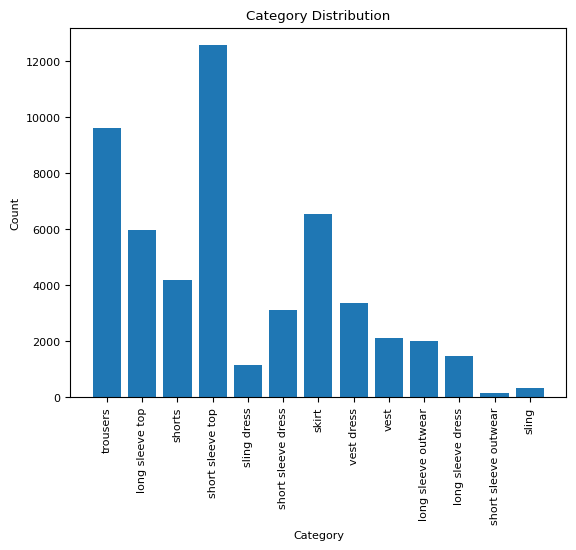

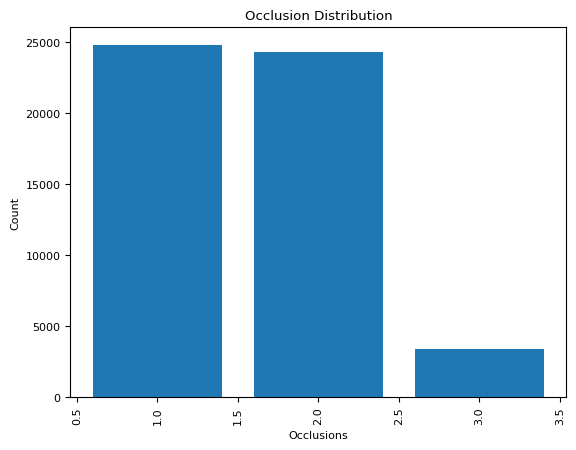

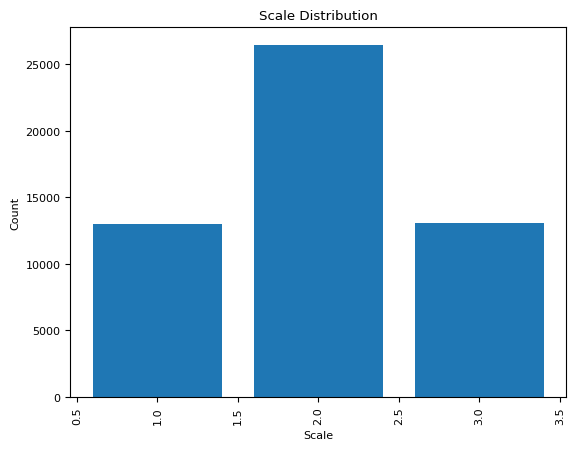

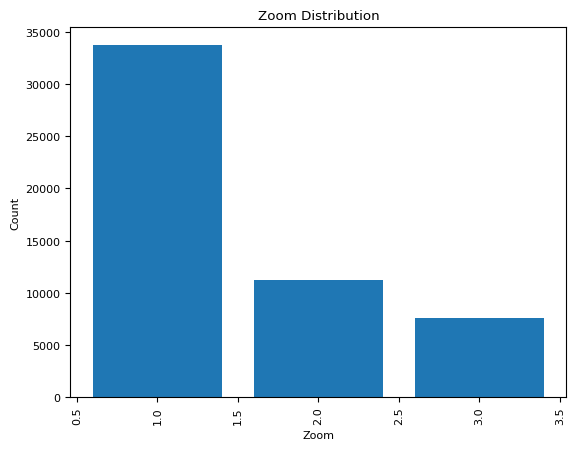

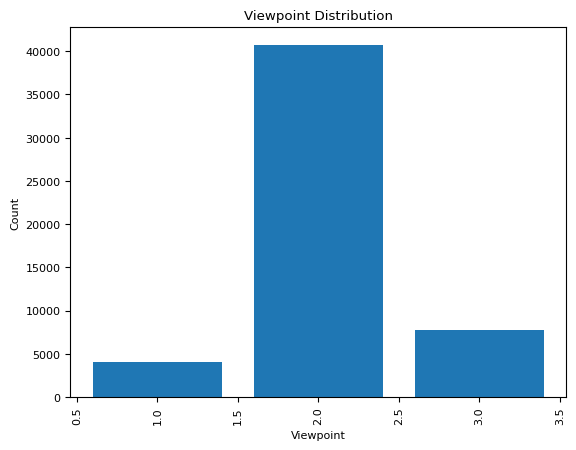

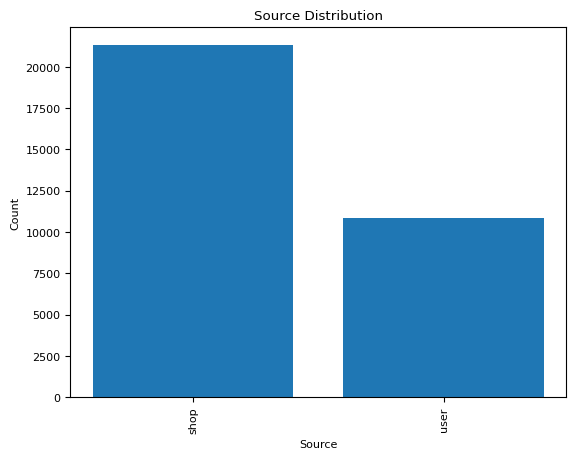

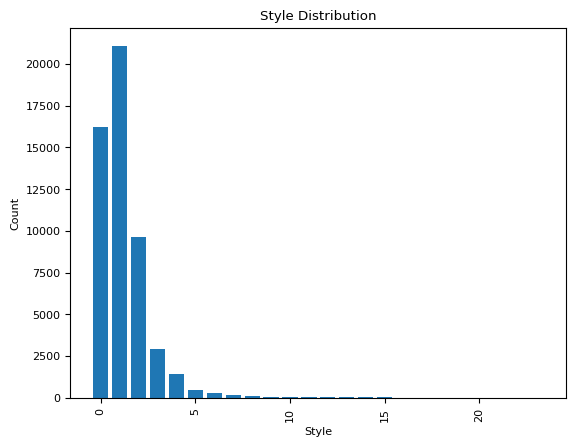

In [13]:
# Analyze the image information
IMAGE_INFO_DIR = Path("/content/validation/annos")

total_image_count = 0
num_images_w_pairs = 0
items_w_occlusions = 0
items_in_image_count = defaultdict(int)
category_count = defaultdict(int)
occlusion_count = defaultdict(int)
scale_count = defaultdict(int)
zoom_in_count = defaultdict(int)
view_point_count = defaultdict(int)
source_count = defaultdict(int)
style_count = defaultdict(int)

# For storage
multi_item_images = []
images_in_cat = defaultdict(list)

# Go through all image information files to distill statistics for charts
for json_file in IMAGE_INFO_DIR.glob("*.json"):

    with json_file.open() as f:
        data = json.load(f)

    image_id = json_file.stem

    source = data['source']
    dict_keys = list(data.keys())
    items = [k for k in dict_keys if 'item' in k]
    num_items = len(items)

    # Update image tally
    total_image_count += 1

    # Update pair count
    if 'pair_id' in dict_keys:
        num_images_w_pairs += 1

    # Update items in image count
    items_in_image_count[num_items] += 1
    if num_items > 1:
        multi_item_images.append({"Image_Id": image_id, "Num_Items": num_items})

    # Update source count
    source_count[source] += 1

    # Update item info:
    for item in items:
        item_info = data.get(item)
        scale = item_info.get('scale')
        style = item_info.get('style')
        occlusion = item_info.get('occlusion')
        cat_id = item_info.get('category_name')
        zoom = item_info.get('zoom_in')
        viewpoint = item_info.get('viewpoint')
        if occlusion > 0:
            items_w_occlusions += 1

        scale_count[scale] += 1
        style_count[style] += 1
        occlusion_count[occlusion] += 1
        category_count[cat_id] += 1
        zoom_in_count[zoom] += 1
        view_point_count[viewpoint] += 1

        images_in_cat[cat_id].append(image_id)

# Make dicts into dataframes for better display
items_in_image_count = pd.DataFrame.from_dict(items_in_image_count, orient='index', columns=['count'])
category_count = pd.DataFrame.from_dict(category_count, orient='index', columns=['count'])
occlusion_count = pd.DataFrame.from_dict(occlusion_count, orient='index', columns=['count'])
scale_count = pd.DataFrame.from_dict(scale_count, orient='index', columns=['count'])
zoom_in_count = pd.DataFrame.from_dict(zoom_in_count, orient='index', columns=['count'])
view_point_count = pd.DataFrame.from_dict(view_point_count, orient='index', columns=['count'])
source_count = pd.DataFrame.from_dict(source_count, orient='index', columns=['count'])
style_count = pd.DataFrame.from_dict(style_count, orient='index', columns=['count'])

# Save info to CSV file
multi_item_images = pd.DataFrame(multi_item_images)
multi_item_images.to_csv('multi_item_images.csv', index=False)

img_in_cat = pd.DataFrame({
    'category': list(images_in_cat.keys()),
    'images': list(images_in_cat.values())
})
img_in_cat.to_csv('images_by_category.csv', index=False)

# Plot dataset statistics
font = {'size': 8}
plt.rc('font', **font)

dataset_information = [items_in_image_count, category_count, occlusion_count, scale_count, zoom_in_count, view_point_count, source_count, style_count]
titles = ["Number of Items in Image", "Category Distribution", "Occlusion Distribution", "Scale Distribution", "Zoom Distribution", "Viewpoint Distribution", "Source Distribution", "Style Distribution"]
x_axes = ["Items", "Category", "Occlusions", "Scale", "Zoom", "Viewpoint", "Source", "Style"]

for i, info in enumerate(dataset_information):
    if info.empty:
        print(f"Skipping {titles[i]}")
        continue
    plt.figure()
    plt.bar(info.index, info.iloc[:,0])
    plt.title(titles[i])
    plt.xlabel(x_axes[i])
    plt.xticks(rotation=90)
    plt.ylabel("Count")
    plt.show()

In [14]:
import os
import json
from collections import defaultdict, Counter

annos_path = "/content/validation/annos"

category_counter = Counter()
pair_ids = set()
items_per_image = []
source_counter = Counter()
valid_items = 0
total_items = 0

for file in os.listdir(annos_path):
    with open(os.path.join(annos_path, file)) as f:
        data = json.load(f)

    source = data.get("source", "unknown")
    source_counter[source] += 1

    pair_id = data.get("pair_id")
    if pair_id:
        pair_ids.add(pair_id)

    item_keys = [k for k in data.keys() if "item" in k]
    items_per_image.append(len(item_keys))

    for k in item_keys:
        total_items += 1
        item = data[k]

        if item.get("category_id") is not None:
            valid_items += 1
            category_counter[item["category_id"]] += 1

# Print summary
print("===== DATASET SUMMARY =====")
print(f"Total images: {len(os.listdir(annos_path))}")
print(f"Unique pair_ids (items): {len(pair_ids)}")
print(f"Total items: {total_items}")
print(f"Valid items: {valid_items}")

print("\n===== CATEGORY DISTRIBUTION =====")
for k, v in category_counter.items():
    print(f"Category {k}: {v}")

print("\n===== ITEMS PER IMAGE =====")
print(f"Avg: {sum(items_per_image)/len(items_per_image):.2f}")
print(f"Min: {min(items_per_image)}, Max: {max(items_per_image)}")

print("\n===== SOURCE DISTRIBUTION =====")
print(source_counter)

===== DATASET SUMMARY =====
Total images: 32153
Unique pair_ids (items): 2279
Total items: 52490
Valid items: 52490

===== CATEGORY DISTRIBUTION =====
Category 8: 9586
Category 2: 5966
Category 7: 4167
Category 1: 12556
Category 13: 1149
Category 10: 3127
Category 9: 6522
Category 12: 3352
Category 5: 2113
Category 4: 2011
Category 11: 1477
Category 3: 142
Category 6: 322

===== ITEMS PER IMAGE =====
Avg: 1.63
Min: 1, Max: 5

===== SOURCE DISTRIBUTION =====
Counter({'shop': 21309, 'user': 10844})


In [15]:
from collections import Counter

pair_count = Counter()

for file in os.listdir(annos_path):
    with open(os.path.join(annos_path, file)) as f:
        data = json.load(f)

    pid = data.get("pair_id")
    if pid:
        pair_count[pid] += 1

# Distribution
counts = list(pair_count.values())

print("Items with only 1 sample:", sum(c == 1 for c in counts))
print("Items with >=2 samples:", sum(c >= 2 for c in counts))

Items with only 1 sample: 0
Items with >=2 samples: 2279


### Create Metadata

In [16]:
base_path = "/content/validation"
annos_path = os.path.join(base_path, "annos")
image_path = os.path.join(base_path, "image")
rows = []

for file in os.listdir(annos_path):
    if not file.endswith(".json"):
        continue

    json_file = os.path.join(annos_path, file)

    with open(json_file, "r") as f:
        data = json.load(f)

    img_name = file.replace(".json", ".jpg")
    img_file = os.path.join(image_path, img_name)

    if not os.path.exists(img_file):
        continue

    source = data.get("source", None)
    pair_id = data.get("pair_id", None)

    if pair_id is None:
        continue

    for key in data.keys():
        if "item" not in key:
            continue

        item = data[key]

        category_id = item.get("category_id", None)

        # try both possible names
        bbox = item.get("bounding_box", item.get("bbox", None))

        if category_id is None or bbox is None:
            continue

        rows.append({
            "image_path": img_file,
            "image_name": img_name,
            "source": source,
            "item_id": str(pair_id),
            "pair_id": int(pair_id),
            "split": "query",
            "category_id": int(category_id),
            "bbox": bbox
        })

metadata_df = pd.DataFrame(rows)
metadata_df.to_csv(METADATA_CSV, index=False)

print("Saved:", METADATA_CSV)
print("Rows:", len(metadata_df))
print(metadata_df.head())

query_pairs = set(metadata_df[metadata_df["split"] == "query"]["pair_id"].unique())
gallery_pairs = set(metadata_df[metadata_df["split"] == "gallery"]["pair_id"].unique())
print("Query pairs:", len(query_pairs))
print("Gallery pairs:", len(gallery_pairs))
print("Overlap pairs:", len(query_pairs & gallery_pairs))
print(metadata_df["split"].value_counts())


Saved: /content/metadata.csv
Rows: 52490
                             image_path  image_name source item_id  pair_id  \
0  /content/validation/image/016326.jpg  016326.jpg   shop     611      611   
1  /content/validation/image/016326.jpg  016326.jpg   shop     611      611   
2  /content/validation/image/001980.jpg  001980.jpg   user     421      421   
3  /content/validation/image/001980.jpg  001980.jpg   user     421      421   
4  /content/validation/image/023999.jpg  023999.jpg   shop    1472     1472   

   split  category_id                  bbox  
0  query            8  [349, 283, 465, 519]  
1  query            2  [322, 144, 476, 324]  
2  query            7  [106, 303, 284, 509]  
3  query            1     [34, 1, 342, 345]  
4  query            8  [238, 460, 479, 822]  
Query pairs: 2279
Gallery pairs: 0
Overlap pairs: 0
split
query    52490
Name: count, dtype: int64


In [17]:
#Remove rows with invalid box
def valid_bbox(bbox):
    if not isinstance(bbox, (list, tuple)) or len(bbox) != 4:
        return False
    x1, y1, x2, y2 = bbox
    return x2 > x1 and y2 > y1

metadata_df = metadata_df[metadata_df["bbox"].apply(valid_bbox)].copy()
print("After bbox cleaning:", len(metadata_df))

After bbox cleaning: 52490


In [18]:
#Keep only items with at least 2 samples
item_counts = metadata_df["item_id"].value_counts()
valid_item_ids = item_counts[item_counts >= 2].index

metadata_df = metadata_df[metadata_df["item_id"].isin(valid_item_ids)].copy()
print("After min-2 filtering:", len(metadata_df))
print("Unique item_ids:", metadata_df["item_id"].nunique())

After min-2 filtering: 52490
Unique item_ids: 2279


In [19]:
#Filter categories
TARGET_CATEGORIES = [1, 8]

metadata_df = metadata_df[metadata_df["category_id"].isin(TARGET_CATEGORIES)].copy()
print("After category filter:", len(metadata_df))
print(metadata_df["category_id"].value_counts().sort_index())

After category filter: 22142
category_id
1    12556
8     9586
Name: count, dtype: int64


In [20]:
#Save the clean metadata CSV
save_dir = "/content/drive/MyDrive/Deep_Learning/project_deepfashion2/data"
os.makedirs(save_dir, exist_ok=True)

metadata_csv = os.path.join(save_dir, "metadata_clean.csv")
metadata_df.to_csv(metadata_csv, index=False)

print("Saved metadata CSV to:")
print(metadata_csv)

print("Rows:", len(metadata_df))
print(metadata_df.head())

Saved metadata CSV to:
/content/drive/MyDrive/Deep_Learning/project_deepfashion2/data/metadata_clean.csv
Rows: 22142
                             image_path  image_name source item_id  pair_id  \
0  /content/validation/image/016326.jpg  016326.jpg   shop     611      611   
3  /content/validation/image/001980.jpg  001980.jpg   user     421      421   
4  /content/validation/image/023999.jpg  023999.jpg   shop    1472     1472   
5  /content/validation/image/023999.jpg  023999.jpg   shop    1472     1472   
6  /content/validation/image/024520.jpg  024520.jpg   shop    1522     1522   

   split  category_id                  bbox  
0  query            8  [349, 283, 465, 519]  
3  query            1     [34, 1, 342, 345]  
4  query            8  [238, 460, 479, 822]  
5  query            1  [228, 164, 496, 525]  
6  query            1   [15, 156, 457, 614]  


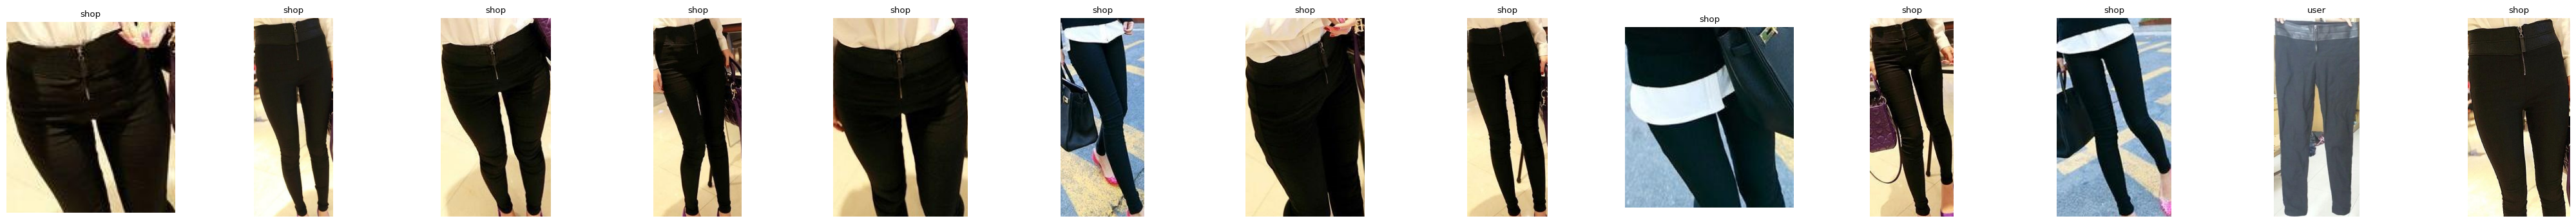

In [21]:
import matplotlib.pyplot as plt
from PIL import Image

def show_pair(pair_id):
    rows = metadata_df[metadata_df["pair_id"] == pair_id]

    fig, axes = plt.subplots(1, len(rows), figsize=(4*len(rows), 4))

    for i, (_, row) in enumerate(rows.iterrows()):
        img = Image.open(row["image_path"]).convert("RGB")
        x1, y1, x2, y2 = map(int, row["bbox"])
        crop = img.crop((x1, y1, x2, y2))

        axes[i].imshow(crop)
        axes[i].set_title(f"{row['source']}")
        axes[i].axis("off")

    plt.show()

show_pair(1510)

In [22]:
pair_id = 1510
samples = metadata_df[metadata_df["pair_id"] == pair_id]
print(samples[["image_path", "source", "bbox"]])

                                 image_path source                  bbox
1450   /content/validation/image/024449.jpg   shop  [323, 309, 447, 449]
5435   /content/validation/image/024446.jpg   shop   [105, 11, 346, 616]
5558   /content/validation/image/024440.jpg   shop  [260, 437, 425, 735]
6961   /content/validation/image/024441.jpg   shop  [253, 346, 430, 744]
11356  /content/validation/image/024443.jpg   shop  [234, 541, 433, 835]
13837  /content/validation/image/024447.jpg   shop  [187, 325, 302, 598]
22927  /content/validation/image/024448.jpg   shop  [307, 499, 502, 824]
25000  /content/validation/image/024444.jpg   shop  [257, 366, 414, 754]
26664  /content/validation/image/024442.jpg   shop  [193, 480, 374, 674]
29304  /content/validation/image/024439.jpg   shop  [254, 424, 394, 757]
45258  /content/validation/image/024450.jpg   shop  [200, 364, 325, 581]
47107  /content/validation/image/006972.jpg   user    [34, 55, 232, 515]
52401  /content/validation/image/024445.jpg   shop 

### Splitting data

In [23]:
#Split into gallery and query
gallery_df = metadata_df[metadata_df["source"] == "shop"].copy()
query_df   = metadata_df[metadata_df["source"] == "user"].copy()

# Ensure valid queries
gallery_items = set(gallery_df["item_id"].unique())
query_df = query_df[query_df["item_id"].isin(gallery_items)].copy()

print("Gallery size:", len(gallery_df))
print("Query size:", len(query_df))
print("Gallery unique items:", gallery_df["item_id"].nunique())
print("Query unique items:", query_df["item_id"].nunique())


Gallery size: 16534
Query size: 5118
Gallery unique items: 1443
Query unique items: 1207


In [24]:
common_items = set(query_df["item_id"]).intersection(set(gallery_df["item_id"]))
item_id = list(common_items)[10]

print("Selected item_id:", item_id)

query_samples = query_df[query_df["item_id"] == item_id].copy()
gallery_samples = gallery_df[gallery_df["item_id"] == item_id].copy()

print("Query samples:", len(query_samples))
print("Gallery samples:", len(gallery_samples))

display(query_samples[["image_path", "source", "item_id", "bbox"]].head())
display(gallery_samples[["image_path", "source", "item_id", "bbox"]].head())

Selected item_id: 716
Query samples: 3
Gallery samples: 4


,image_path,source,item_id,bbox
29908,/content/validation/image/003360.jpg,user,716,"[115, 9, 467, 535]"
33469,/content/validation/image/003359.jpg,user,716,"[162, 2, 466, 414]"
45325,/content/validation/image/003361.jpg,user,716,"[1, 1, 466, 605]"


,image_path,source,item_id,bbox
35414,/content/validation/image/017425.jpg,shop,716,"[191, 278, 467, 539]"
35416,/content/validation/image/017425.jpg,shop,716,"[0, 56, 368, 471]"
39599,/content/validation/image/017426.jpg,shop,716,"[129, 52, 466, 427]"
39601,/content/validation/image/017426.jpg,shop,716,"[1, 272, 290, 545]"


In [25]:
overlap_images = set(query_df["image_path"]).intersection(set(gallery_df["image_path"]))
print("Shared image paths:", len(overlap_images))

Shared image paths: 0


In [26]:
# no exact image leakage
set(gallery_df["image_path"]).intersection(set(query_df["image_path"]))

set()

count    1625.000000
mean       13.625846
std        11.866938
min         1.000000
25%         6.000000
50%        11.000000
75%        18.000000
max        92.000000
Name: count, dtype: float64


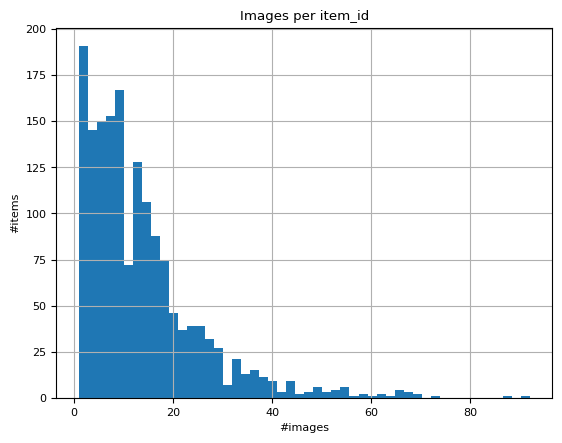

In [27]:
counts = metadata_df["item_id"].value_counts()

print(counts.describe())

import matplotlib.pyplot as plt
counts.hist(bins=50)
plt.title("Images per item_id")
plt.xlabel("#images")
plt.ylabel("#items")
plt.show()

In [28]:
print("Items with 1 image:", (counts == 1).sum())

Items with 1 image: 101


In [29]:
#removing item with 1 image
valid_items = counts[counts >= 2].index
metadata_df = metadata_df[metadata_df["item_id"].isin(valid_items)]

count    1207.000000
mean        4.240265
std         5.226251
min         1.000000
25%         1.000000
50%         2.000000
75%         5.000000
max        41.000000
Name: count, dtype: float64


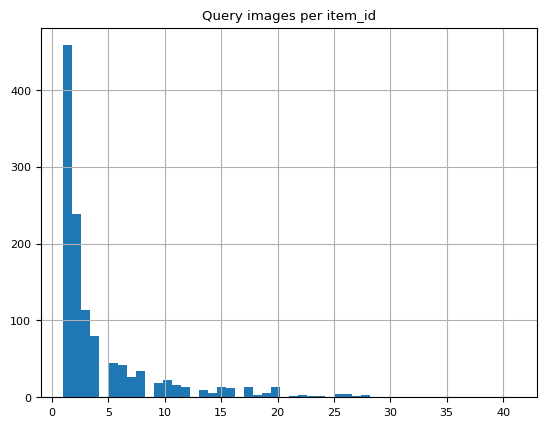

In [30]:
query_counts = query_df["item_id"].value_counts()

print(query_counts.describe())

query_counts.hist(bins=50)
plt.title("Query images per item_id")
plt.show()

count    1443.000000
mean       11.458073
std        10.261904
min         1.000000
25%         5.000000
50%         9.000000
75%        15.000000
max        78.000000
Name: count, dtype: float64


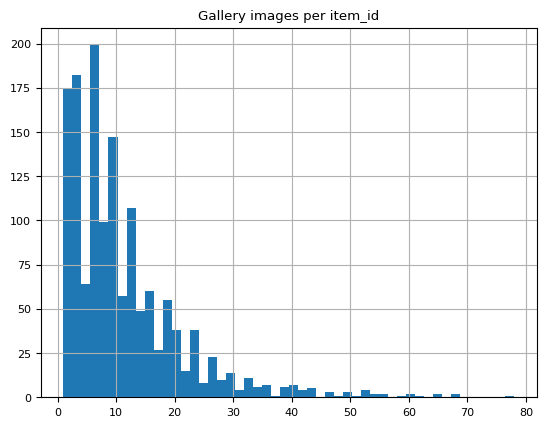

In [31]:
gallery_counts = gallery_df["item_id"].value_counts()

print(gallery_counts.describe())

gallery_counts.hist(bins=50)
plt.title("Gallery images per item_id")
plt.show()

count    5118.000000
mean       12.889996
std        12.073945
min         1.000000
25%         5.000000
50%         9.000000
75%        17.000000
max        78.000000
Name: num_gallery_matches, dtype: float64


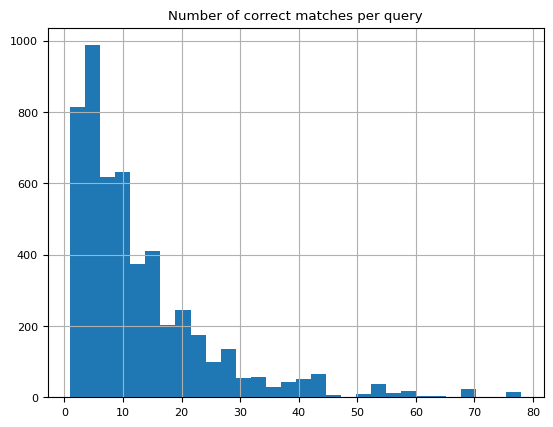

In [32]:
gallery_counts = gallery_df["item_id"].value_counts()

query_df["num_gallery_matches"] = query_df["item_id"].map(gallery_counts)

print(query_df["num_gallery_matches"].describe())

query_df["num_gallery_matches"].hist(bins=30)
plt.title("Number of correct matches per query")
plt.show()